# 🏥 7주차 실습 — 정답 없이도 배운다
## 비지도학습 & K-Means 군집화

**보건의료 데이터 분석 입문**  
실습 데이터: Pima Indian Diabetes Dataset (768명, 8개 특성)

---
| 단계 | 내용 |
|------|------|
| STEP 1 | 데이터 불러오기 & 탐색 |
| STEP 2 | 레이블 제거 & 데이터 전처리 |
| STEP 3 | K-Means 학습 (K=3) |
| STEP 4 | 시각화 — PCA 2D 산점도 |
| STEP 5 | K값 비교 (K=2, 3, 4) |
| STEP 6 | 정답(레이블)과 군집 결과 비교 |
| BONUS | 엘보우 기법으로 최적 K 찾기 |


## ⚙️ STEP 0 — 라이브러리 불러오기

In [1]:
import os
import shutil
import warnings

warnings.filterwarnings('ignore')

# 코랩/리눅스 한글 폰트 설치 및 설정
if shutil.which('apt-get'):
    os.system('apt-get -qq update')
    os.system('apt-get -qq install -y fonts-nanum > /dev/null 2>&1')
    os.system('fc-cache -fv > /dev/null 2>&1')
    os.system('rm -rf /root/.cache/matplotlib')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# 폰트 파일 직접 지정 (코랩에서 가장 안정적)
font_candidates = [
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
]
font_path = next((p for p in font_candidates if os.path.exists(p)), None)

if font_path:
    fontprop = fm.FontProperties(fname=font_path)
    font_name = fontprop.get_name()
    fm.fontManager.addfont(font_path)
else:
    fontprop = None
    font_name = 'DejaVu Sans'

matplotlib.rcParams['font.family'] = [font_name, 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['savefig.dpi'] = 120


def apply_korean_font(ax=None):
    """제목, 축, 눈금, 범례까지 한글 폰트 강제 적용"""
    if fontprop is None:
        return
    targets = []
    if ax is None:
        fig = plt.gcf()
        targets = fig.axes
    else:
        targets = [ax]

    for a in targets:
        a.title.set_fontproperties(fontprop)
        a.xaxis.label.set_fontproperties(fontprop)
        a.yaxis.label.set_fontproperties(fontprop)

        for label in a.get_xticklabels() + a.get_yticklabels():
            label.set_fontproperties(fontprop)

        leg = a.get_legend()
        if leg is not None:
            for txt in leg.get_texts():
                txt.set_fontproperties(fontprop)
            if leg.get_title() is not None:
                leg.get_title().set_fontproperties(fontprop)


def apply_font_to_figure(fig=None):
    if fontprop is None:
        return
    if fig is None:
        fig = plt.gcf()
    for ax in fig.axes:
        apply_korean_font(ax)
        for txt in ax.texts:
            txt.set_fontproperties(fontprop)
    if getattr(fig, '_suptitle', None) is not None:
        fig._suptitle.set_fontproperties(fontprop)

print('✅ 모든 라이브러리 로드 완료!')
print('✅ 적용 폰트:', font_name)
print('✅ 폰트 파일:', font_path if font_path else '기본 폰트 사용')


✅ 모든 라이브러리 로드 완료!
✅ 적용 폰트: NanumGothic
✅ 폰트 파일: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


---
## 📥 STEP 1 — 데이터 불러오기

Pima Indian Diabetes Dataset을 불러옵니다.  
총 **768명** 환자, **8개 특성 변수** + **1개 정답(Outcome)** 열로 구성됩니다.


In [2]:
# sklearn에서 데이터 불러오기
from sklearn.datasets import fetch_openml

# CSV URL로 직접 불러오기 (인터넷 연결 필요)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df = pd.read_csv(url, names=col_names)
    print("✅ 인터넷에서 데이터 로드 성공!")
except:
    # 오프라인 대체: 직접 생성
    np.random.seed(42)
    n = 768
    df = pd.DataFrame({
        'Pregnancies': np.random.randint(0, 17, n),
        'Glucose': np.random.randint(70, 200, n),
        'BloodPressure': np.random.randint(40, 120, n),
        'SkinThickness': np.random.randint(10, 60, n),
        'Insulin': np.random.randint(15, 350, n),
        'BMI': np.round(np.random.uniform(18, 50, n), 1),
        'DiabetesPedigreeFunction': np.round(np.random.uniform(0.07, 2.42, n), 3),
        'Age': np.random.randint(21, 82, n),
        'Outcome': np.random.randint(0, 2, n),
    })
    print("⚠️  오프라인 모드: 예시 데이터를 생성했습니다.")

print(f"\n📊 데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
df.head(10)


✅ 인터넷에서 데이터 로드 성공!

📊 데이터 크기: 768행 × 9열


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
# 기본 정보 확인
print("=== 데이터 정보 ===")
df.info()
print("\n=== 기초 통계량 ===")
df.describe().round(2)


=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== 기초 통계량 ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


=== 당뇨 여부 분포 ===
정상 (0): 500명 (65.1%)
당뇨 (1): 268명 (34.9%)


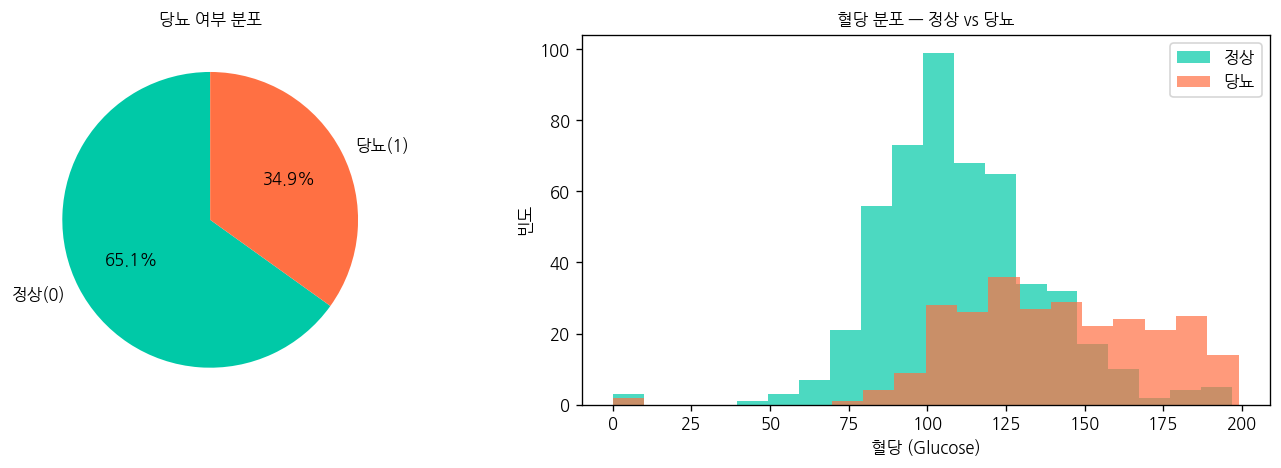

In [4]:
# 당뇨 여부 분포 확인
count = df['Outcome'].value_counts()
print("=== 당뇨 여부 분포 ===")
print(f"정상 (0): {count[0]}명 ({count[0]/len(df)*100:.1f}%)")
print(f"당뇨 (1): {count[1]}명 ({count[1]/len(df)*100:.1f}%)")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 파이차트
wedges, texts, autotexts = axes[0].pie(
    count,
    labels=['정상(0)', '당뇨(1)'],
    autopct='%1.1f%%',
    colors=['#00C9A7', '#FF7043'],
    startangle=90
)
axes[0].set_title('당뇨 여부 분포', fontsize=13, fontweight='bold')

# 히스토그램 — 혈당
axes[1].hist(df[df['Outcome']==0]['Glucose'], bins=20, alpha=0.7,
             color='#00C9A7', label='정상')
axes[1].hist(df[df['Outcome']==1]['Glucose'], bins=20, alpha=0.7,
             color='#FF7043', label='당뇨')
axes[1].set_xlabel('혈당 (Glucose)')
axes[1].set_ylabel('빈도')
axes[1].set_title('혈당 분포 — 정상 vs 당뇨', fontsize=13, fontweight='bold')
axes[1].legend()

for t in texts + autotexts:
    if fontprop is not None:
        t.set_fontproperties(fontprop)
apply_font_to_figure(fig)

plt.tight_layout()
plt.show()

---
## 🏷️ STEP 2 — 레이블 제거 & 데이터 전처리

> 💡 **비지도학습의 핵심**: 정답(Outcome)을 보지 않고 X만으로 패턴을 찾습니다!


In [5]:
# 정답 열 분리 저장 (나중에 비교용)
y_true = df['Outcome'].copy()

# X: 특성 변수만 남기기 (정답 열 제거)
X = df.drop('Outcome', axis=1)

print(f"X (입력 특성) 크기: {X.shape}")
print(f"y (정답 레이블) 크기: {y_true.shape}")
print(f"\n특성 변수 목록: {list(X.columns)}")
print("\n✅ 이제 모델은 X만 보고 패턴을 찾습니다!")


X (입력 특성) 크기: (768, 8)
y (정답 레이블) 크기: (768,)

특성 변수 목록: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

✅ 이제 모델은 X만 보고 패턴을 찾습니다!


In [6]:
# 데이터 정규화 — K-Means는 거리 기반이므로 스케일 맞추기 필수!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== 정규화 전 (Glucose 기준) ===")
print(f"평균: {X['Glucose'].mean():.1f}, 표준편차: {X['Glucose'].std():.1f}")
print(f"\n=== 정규화 후 ===")
print(f"평균: {X_scaled[:, 1].mean():.4f}, 표준편차: {X_scaled[:, 1].std():.4f}")
print("\n✅ 모든 변수가 평균=0, 표준편차=1로 정규화되었습니다!")


=== 정규화 전 (Glucose 기준) ===
평균: 120.9, 표준편차: 32.0

=== 정규화 후 ===
평균: -0.0000, 표준편차: 1.0000

✅ 모든 변수가 평균=0, 표준편차=1로 정규화되었습니다!


---
## ⚙️ STEP 3 — K-Means 학습 (K=3)

K-Means 알고리즘 4단계:
1. 중심점 K개 **랜덤 배치**
2. 각 데이터를 **가장 가까운 중심점에 배정**
3. 중심점을 **군집 평균으로 이동**
4. 변화 없을 때까지 **반복 → 수렴**


In [7]:
# K-Means 학습 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

labels = kmeans.labels_

print(f"=== K-Means 학습 완료 (K=3) ===")
print(f"반복 횟수: {kmeans.n_iter_}회")
print(f"Inertia (군집 내 분산 합): {kmeans.inertia_:.2f}")

print(f"\n=== 군집별 데이터 수 ===")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  군집 {u}: {c}명 ({c/len(labels)*100:.1f}%)")


=== K-Means 학습 완료 (K=3) ===
반복 횟수: 20회
Inertia (군집 내 분산 합): 4359.94

=== 군집별 데이터 수 ===
  군집 0: 216명 (28.1%)
  군집 1: 337명 (43.9%)
  군집 2: 215명 (28.0%)


In [8]:
# 군집별 특성 평균 비교
df_result = X.copy()
df_result['Cluster'] = labels

cluster_summary = df_result.groupby('Cluster').mean().round(2)
print("=== 군집별 특성 평균 ===")
cluster_summary


=== 군집별 특성 평균 ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,2.64,138.78,73.43,34.83,192.04,36.90,0.60,30.63
1,2.29,103.37,61.13,15.24,36.04,28.50,0.40,26.31
2,7.49,130.39,77.26,14.48,35.63,32.54,0.46,46.73


---
## 📊 STEP 4 — 시각화 — PCA 2D 산점도

> 💡 8차원 데이터를 2차원으로 압축해서 눈으로 확인합니다.  
> PCA는 **시각화용**으로만 사용하며, 학습은 원본 8차원으로 했습니다!


In [9]:
# PCA로 2차원 압축
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"PC1 설명 분산: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 설명 분산: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"총 설명 분산: {sum(pca.explained_variance_ratio_)*100:.1f}%")


PC1 설명 분산: 26.2%
PC2 설명 분산: 21.6%
총 설명 분산: 47.8%


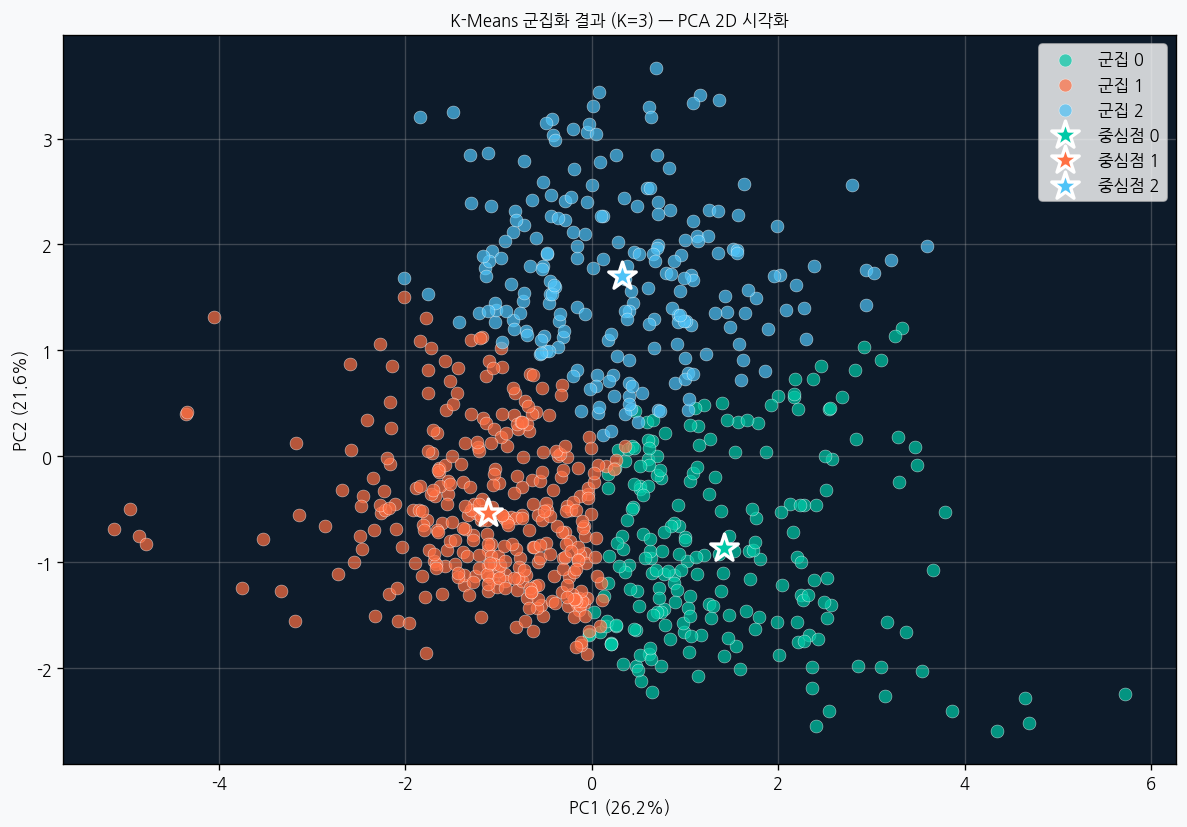

⭐ 색깔별로 3개 그룹이 구분됩니다!


In [11]:
# K=3 군집화 결과 시각화
colors = ['#00C9A7', '#FF7043', '#4FC3F7']
cluster_names = ['군집 0', '군집 1', '군집 2']

fig, ax = plt.subplots(figsize=(10, 7))

for i in range(3):
    mask = labels == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[i], label=cluster_names[i],
               alpha=0.7, s=60, edgecolors='white', linewidth=0.3)

# 중심점 표시
centers_2d = pca.transform(kmeans.cluster_centers_)
for i, center in enumerate(centers_2d):
    ax.scatter(center[0], center[1], c=colors[i],
               s=300, marker='*', edgecolors='white', linewidth=2,
               zorder=5, label=f'중심점 {i}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('K-Means 군집화 결과 (K=3) — PCA 2D 시각화', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#0D1B2A')
fig.patch.set_facecolor('#F8F9FA')

apply_font_to_figure(fig)

plt.tight_layout()
plt.show()
print("⭐ 색깔별로 3개 그룹이 구분됩니다!")

---
## 🔢 STEP 5 — K값 비교 (K=2, 3, 4)

> K가 너무 작으면 과소분류, 너무 크면 과잉분류 됩니다.  
> 결과를 나란히 비교해 보겠습니다!


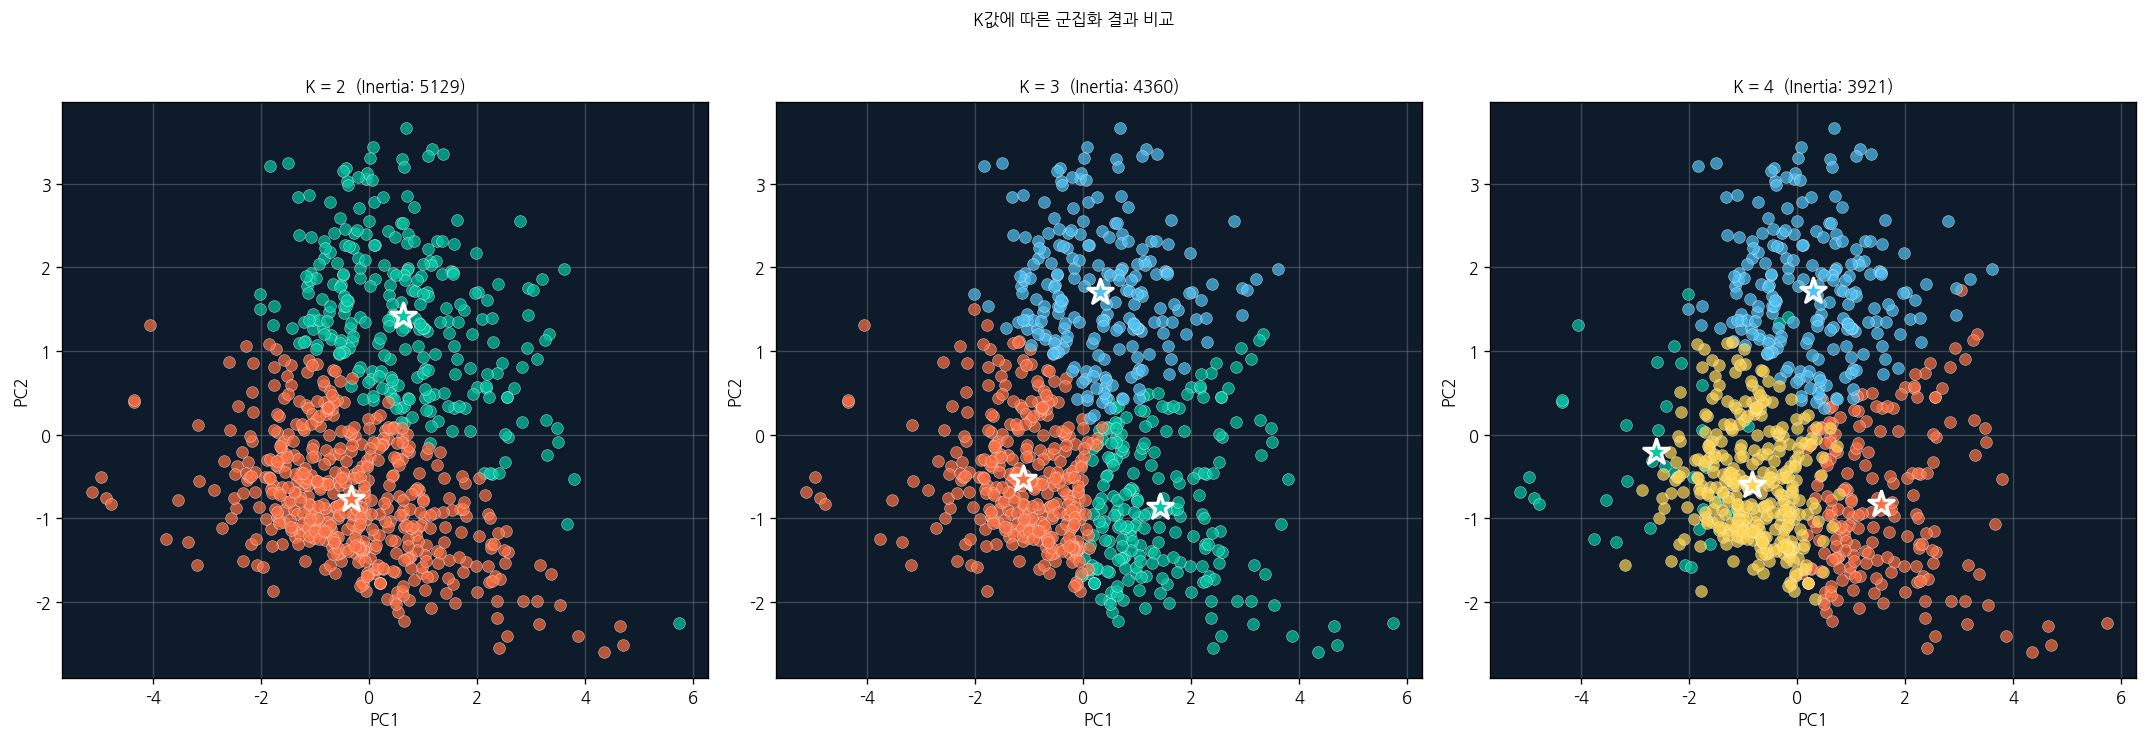

💡 K가 클수록 세분화되지만, 해석과 활용의 복잡도도 높아집니다.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
k_list = [2, 3, 4]
color_sets = [
    ['#00C9A7', '#FF7043'],
    ['#00C9A7', '#FF7043', '#4FC3F7'],
    ['#00C9A7', '#FF7043', '#4FC3F7', '#FFD54F'],
]

all_labels = {}

for ax, k, cols in zip(axes, k_list, color_sets):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    all_labels[k] = lbl

    for i in range(k):
        mask = lbl == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=cols[i], alpha=0.7, s=50,
                   edgecolors='white', linewidth=0.3)

    # 중심점
    centers = pca.transform(km.cluster_centers_)
    for i, c in enumerate(centers):
        ax.scatter(c[0], c[1], c=cols[i], s=250, marker='*',
                   edgecolors='white', linewidth=2, zorder=5)

    ax.set_title(f'K = {k}  (Inertia: {km.inertia_:.0f})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0D1B2A')

plt.suptitle('K값에 따른 군집화 결과 비교', fontsize=15, fontweight='bold', y=1.02)
apply_font_to_figure(fig)
plt.tight_layout()
plt.show()

print("💡 K가 클수록 세분화되지만, 해석과 활용의 복잡도도 높아집니다.")

---
## 🔍 STEP 6 — 정답(레이블)과 군집 결과 비교

> 이제 처음에 따로 저장해둔 정답(y_true)과 비교해봅니다!  
> K-Means는 **분류가 목적이 아니므로** 완벽한 일치를 기대하기 어렵지만,  
> 의미있는 패턴을 발견했는지 확인할 수 있습니다.


In [13]:
# Adjusted Rand Index — 군집과 정답 일치도 측정
ari_k3 = adjusted_rand_score(y_true, labels)
print(f"=== Adjusted Rand Index (K=3) ===")
print(f"ARI: {ari_k3:.3f}  (범위: -1 ~ 1, 높을수록 정답과 유사)")

# 교차표: 군집 vs 실제 당뇨 여부
ct = pd.crosstab(labels, y_true,
                 rownames=['군집'], colnames=['실제 당뇨(Outcome)'])
ct.index = [f'군집 {i}' for i in ct.index]
print("\n=== 교차표 (군집 vs 실제 당뇨 여부) ===")
print(ct)
print(f"\n각 행 합계: {ct.sum(axis=1).to_dict()}")


=== Adjusted Rand Index (K=3) ===
ARI: 0.122  (범위: -1 ~ 1, 높을수록 정답과 유사)

=== 교차표 (군집 vs 실제 당뇨 여부) ===
실제 당뇨(Outcome)    0    1
군집 0            106  110
군집 1            287   50
군집 2            107  108

각 행 합계: {'군집 0': 216, '군집 1': 337, '군집 2': 215}


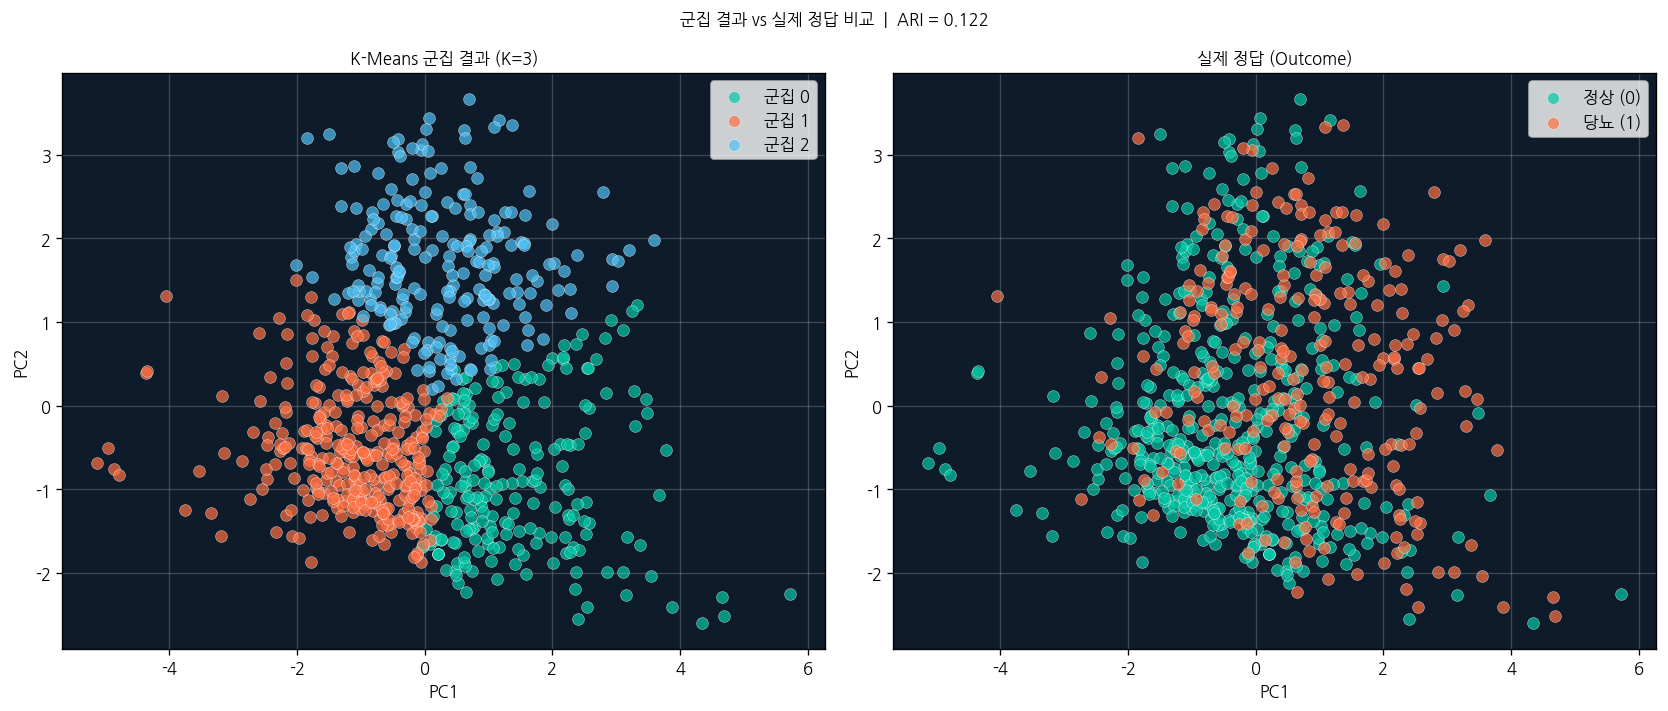

In [14]:
# 시각화: 군집 결과 vs 실제 정답 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 군집 결과 (K=3)
colors_cluster = ['#00C9A7', '#FF7043', '#4FC3F7']
for i in range(3):
    mask = labels == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors_cluster[i], alpha=0.7, s=50,
                    edgecolors='white', linewidth=0.3, label=f'군집 {i}')
axes[0].set_title('K-Means 군집 결과 (K=3)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#0D1B2A')

# 오른쪽: 실제 정답
colors_true = ['#00C9A7', '#FF7043']
labels_true = ['정상 (0)', '당뇨 (1)']
for i in range(2):
    mask = y_true == i
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors_true[i], alpha=0.7, s=50,
                    edgecolors='white', linewidth=0.3, label=labels_true[i])
axes[1].set_title('실제 정답 (Outcome)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#0D1B2A')

plt.suptitle(f'군집 결과 vs 실제 정답 비교  |  ARI = {ari_k3:.3f}',
             fontsize=14, fontweight='bold')
apply_font_to_figure(fig)
plt.tight_layout()
plt.show()

In [15]:
# 군집별 당뇨 비율 분석
print("=== 군집별 당뇨 비율 ===")
for c in range(3):
    mask = labels == c
    n_total = mask.sum()
    n_diabetes = (y_true[mask] == 1).sum()
    ratio = n_diabetes / n_total * 100
    bar = '█' * int(ratio / 5)
    print(f"군집 {c}: {n_total:3d}명 | 당뇨 {n_diabetes:3d}명 ({ratio:.1f}%) {bar}")

print("\n💡 당뇨 비율이 높은 군집 → 고위험군으로 추정 가능!")


=== 군집별 당뇨 비율 ===
군집 0: 216명 | 당뇨 110명 (50.9%) ██████████
군집 1: 337명 | 당뇨  50명 (14.8%) ██
군집 2: 215명 | 당뇨 108명 (50.2%) ██████████

💡 당뇨 비율이 높은 군집 → 고위험군으로 추정 가능!


---
## 🎯 BONUS — 엘보우(Elbow) 기법으로 최적 K 찾기

> **Inertia**: 각 데이터 포인트와 소속 군집 중심점 사이 거리의 합  
> K가 증가할수록 Inertia는 감소하지만, **감소폭이 급격히 줄어드는 지점(팔꿈치)** 이 최적 K입니다.


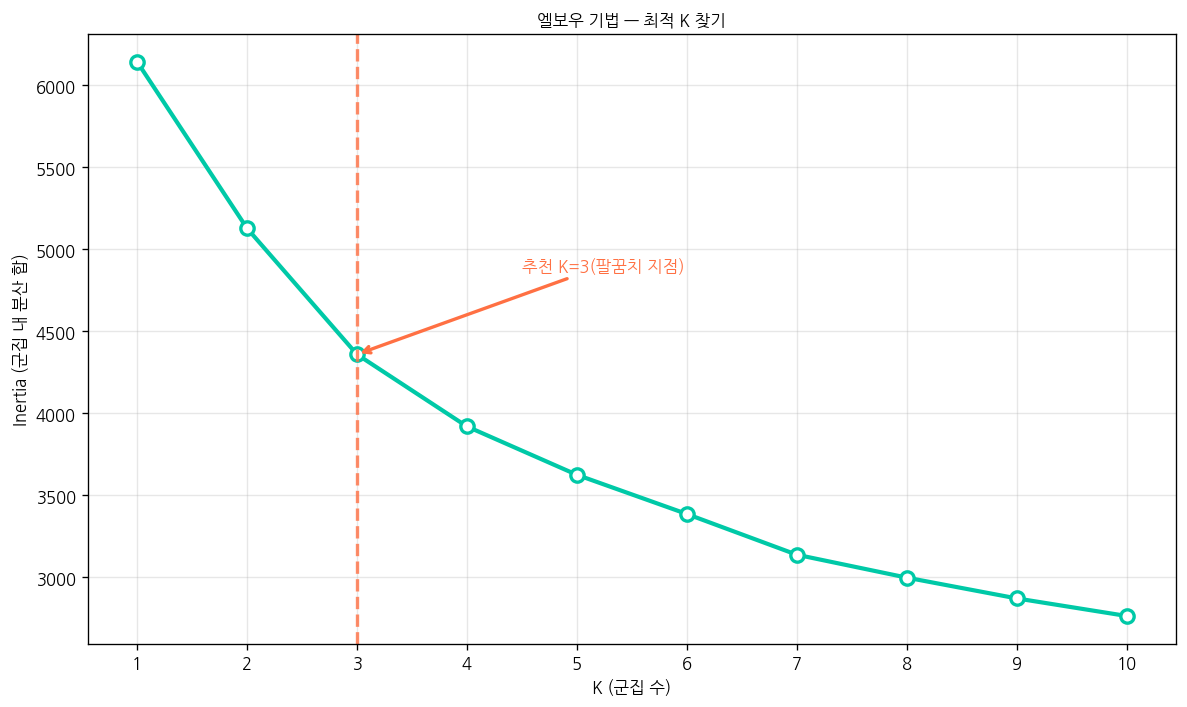

K값별 Inertia:
  K= 1:   6144.0  ████████████████████
  K= 2:   5128.8  ████████████████
  K= 3:   4359.9  ██████████████
  K= 4:   3920.6  ████████████
  K= 5:   3625.7  ███████████
  K= 6:   3386.9  ███████████
  K= 7:   3138.6  ██████████
  K= 8:   2999.0  █████████
  K= 9:   2872.3  █████████
  K=10:   2765.2  █████████


In [18]:
# 다양한 K값에서 Inertia 계산
k_range = range(1, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# 엘보우 그래프
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(list(k_range), inertias, 'o-',
        color='#00C9A7', linewidth=2.5, markersize=8,
        markerfacecolor='white', markeredgewidth=2)

# 최적 K 강조 (K=3)
ax.axvline(x=3, color='#FF7043', linestyle='--', alpha=0.8, linewidth=2)
ax.annotate('추천 K=3(팔꿈치 지점)', xy=(3, inertias[2]),
            xytext=(4.5, inertias[2] + (inertias[0]-inertias[-1])*0.15),
            fontsize=12, color='#FF7043', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#FF7043', lw=2))

ax.set_xlabel('K (군집 수)', fontsize=13)
ax.set_ylabel('Inertia (군집 내 분산 합)', fontsize=13)
ax.set_title('엘보우 기법 — 최적 K 찾기', fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.3)

apply_font_to_figure(fig)
plt.tight_layout()
plt.show()

print(f"K값별 Inertia:")
for k, iner in zip(k_range, inertias):
    bar = '█' * int(iner / inertias[0] * 20)
    print(f"  K={k:2d}: {iner:8.1f}  {bar}")

---
## 🎓 실습 마무리

### 오늘 배운 것

| 개념 | 핵심 내용 |
|------|-----------|
| **비지도학습** | 정답(Y) 없이 X만으로 패턴을 스스로 발견 |
| **K-Means** | K개 중심점으로 데이터를 군집화 (4단계 반복) |
| **PCA 시각화** | 고차원 데이터를 2D로 압축해서 군집 확인 |
| **K 선택** | 엘보우 기법으로 최적 K를 탐색 |
| **결과 해석** | 군집별 특성 평균 + 실제 레이블과 비교 |

### 다음 시간 미리보기
9주차: 딥러닝의 시작 — 뉴럴 네트워크와 퍼셉트론  
> 💡 K-Means의 '가중치 반복 최적화' 아이디어가 딥러닝에서도 핵심 원리로 등장합니다!

---
*수고하셨습니다! 🎉*
